# Simplest use case

## Running a model from the config file

Setting up the `dolphin` ecosystem:

- Install `dolphin`, `lenstronomy`, and the required dependencies.
- Create an input/output directory for `dolphin`, we are using "../io_directory_example" in this example.
- Set up these directories inside the input/output directory. Look inside "../io_directory_example" for example. 
    - **data**: contains subdirectories for each lens system with a data and PSF files for each band.
    - **settings**: contains the 'config_{lens_name}.yaml' files for each lens system,
        - **masks**: contains the custom 'mask_{lens_name}_{band}.npy' files (optional),
    - **logs**: to write the log files from model runs,
    - **outputs**: to save the model outputs,
    - **hpc**: *optional*, contains scripts to submit batch jobs in MPI.
 

   
### Data format

The image data file needs to be in the hdf5 format with the following datasets:

- `image_data`: reduced and background subtracted image cutout centered at the lens system,
- `background_rms`: background level,
- `exposure_time`: the map of exposure times for each pixel, so that `image_data * exposure_time` is Poisson noise distributed,
- `ra_at_xy_0`: RA of the (0, 0) pixel in the `image_data` cutout,
- `dec_at_xy_0`: Dec of the (0, 0) pixel in the `image_data` cutout,
- `transform_pix2angle`: a transform matrix to map the pixel numbers (x, y) to angles (RA, Dec).

The PSF data file needs to be in the hdf5 format with the following datasets:

- `kernel_point_source`: a pixelated PSF (not required to have the same dimension of `image_data`),
- `psf_variance_map`: *optional*, uncertainty in the provided PSF, needs to have the same dimension of `kernel_point_source`. 

### Config file format

The 'config_{lens_name}.yaml' file provides you options to set up the lens model. Here is the content of the config file that is used in the example model below.

### Imports

In [1]:
from dolphin.processor import Processor
from dolphin.analysis.output import Output

import os
import multiprocessing

### create a `Processor` instance and point to the IO directory

In [2]:
processor = Processor("../io_directory_example/")

### Run a model by calling the  `swim()` method

In [3]:
processor.swim(lens_name="lens_system2", model_id="example", log=False, thread_count=8, use_nn_mge=True)

Optimizing model for lens_system2 with recipe: galaxy-quasar.


Computing the PSO ...


100%|██████████| 50/50 [00:32<00:00,  1.52it/s]

Max iteration reached! Stopping.
-1.0866503516381565 reduced X^2 of best position
-7797.259598179591 log likelihood
14351 effective number of data points
[{'theta_E': np.float64(1.225818312415961), 'gamma': 2.0, 'e1': np.float64(-0.0010718204996669528), 'e2': np.float64(0.02125519317486388), 'center_x': np.float64(0.042016916341697644), 'center_y': np.float64(-0.03961575029088444)}, {'gamma_ext': np.float64(0.01511705278895635), 'psi_ext': np.float64(0.0691250718342158), 'ra_0': 0, 'dec_0': 0}] lens result
[{'amp': 1, 'n_max': 4, 'beta': np.float64(0.10176847984541008), 'center_x': np.float64(0.05589066750893247), 'center_y': np.float64(-0.26262569046719303)}] source result
[{'amp': 1, 'sigma_min': np.float64(0.07283153507454691), 'sigma_width': np.float64(1.6506741397214202), 'e1': np.float64(-0.10501975427975166), 'e2': np.float64(0.010959146740704424), 'center_x': np.float64(0.042016916341697644), 'center_y': np.float64(-0.03961575029088444)}] lens light result
[] point source resul

Computing the PSO ...


...

Computing the PSO ...


100%|██████████| 50/50 [00:22<00:00,  2.22it/s]

Max iteration reached! Stopping.
-1.047166462239298 reduced X^2 of best position
-7513.419366566964 log likelihood
14350 effective number of data points
[{'theta_E': np.float64(1.2235646199210852), 'gamma': np.float64(2.0010252086295717), 'e1': np.float64(-0.04693776453310747), 'e2': np.float64(0.02410315653993871), 'center_x': np.float64(0.024295867903993212), 'center_y': np.float64(-0.04179841500603201)}, {'gamma_ext': np.float64(1.903237883075475e-06), 'psi_ext': np.float64(0.06739008977287397), 'ra_0': 0, 'dec_0': 0}] lens result
[{'amp': 1, 'n_max': 4, 'beta': np.float64(0.10254103547717054), 'center_x': np.float64(0.04241164889123777), 'center_y': np.float64(-0.25838791451652016)}] source result
[{'amp': 1, 'sigma_min': np.float64(0.0632585146286523), 'sigma_width': np.float64(1.7980548966384144), 'e1': np.float64(-0.10412096021310382), 'e2': np.float64(0.016394096584195317), 'center_x': np.float64(0.024295867903993212), 'center_y': np.float64(-0.04179841500603201)}] lens light r


100%|██████████| 100/100 [01:43<00:00,  1.04s/it]

Computing the MCMC...
Number of walkers =  30
Burn-in iterations:  0
Sampling iterations (in current run): 100
105.28390836715698 time taken for MCMC sampling


One can also perform the fitting sequence through JAXtronomy by setting the `use_jax` flag. For parallelization across CPU cores, an environment variable also needs to be set.

In [4]:
num_cores = multiprocessing.cpu_count()
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=" + str(num_cores)

In [6]:
processor.swim(
    lens_name="lens_system2",
    model_id="example",
    log=False,
    use_jax=True,
    thread_count=2,
    use_nn_mge=False
)

Optimizing model for lens_system2 with recipe: galaxy-quasar.


KeyboardInterrupt: 

## Let's check the output

In [7]:
output = Output("../io_directory_example/")

Loaded output for lens_system2 with model ID example.
dolphin version used: 1.4.0
lenstronomy version used: 1.14.1
-1.047434947380636 reduced X^2 of all evaluated imaging data combined (without degrees of freedom subtracted).
reduced chi^2 of data  0 =  1.047434947380636


/data/bwedig/.conda/envs/kuina/lib/python3.13/site-packages/lenstronomy/Plots/model_band_plot.py:218: RuntimeWarning: invalid value encountered in log10
  np.log10(self._data),
/data/bwedig/.conda/envs/kuina/lib/python3.13/site-packages/lenstronomy/Plots/model_band_plot.py:916: RuntimeWarning: invalid value encountered in log10
  source_scale = np.log10(source)


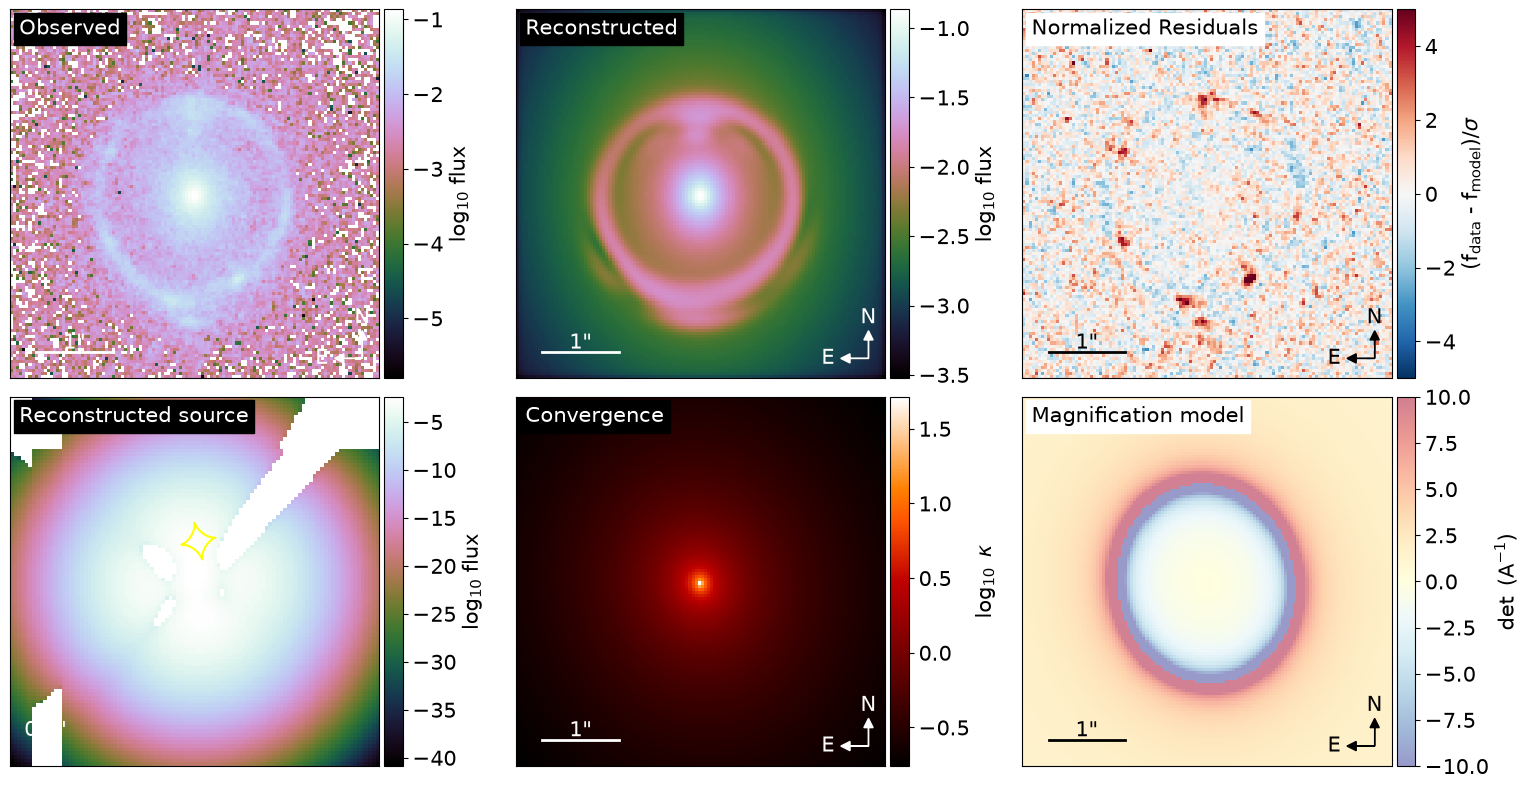

In [8]:
fig = output.plot_model_overview(lens_name="lens_system2", model_id="example")

We only ran a pre-sampling optimization here and did not perform a MCMC sampling. So, the above model is the optimized model that the MCMC sample can initiate from. The `kwargs_result` dictionary of the pre-sampling optimization step can be accessed through `Output.kwargs_result` after loading an output using the `Output.load_output()` method.

In [8]:
output.load_output(lens_name="lens_system2", model_id="example")

output.kwargs_result

{'kwargs_lens': [{'theta_E': 1.2321343340631474,
   'gamma': 1.9945828842690294,
   'e1': -0.05907095482035069,
   'e2': 0.026076431682767565,
   'center_x': 0.028496411995982095,
   'center_y': -0.04468558369823349},
  {'gamma_ext': 0.0002940340255095063,
   'psi_ext': 0.15220142248346613,
   'ra_0': 0,
   'dec_0': 0}],
 'kwargs_source': [{'amp': 1,
   'n_max': 4,
   'beta': 0.10388249634305534,
   'center_x': 0.04024225364982045,
   'center_y': -0.26795631757985144}],
 'kwargs_lens_light': [{'amp': 1,
   'R_sersic': 3.001674909568047,
   'n_sersic': 4.0,
   'e1': -0.1390670139885013,
   'e2': 0.029001439537037637,
   'center_x': 0.028496411995982095,
   'center_y': -0.04468558369823349}],
 'kwargs_ps': [],
 'kwargs_special': {},
 'kwargs_extinction': [],
 'kwargs_tracer_source': []}

When necessary, the settings of the model run---that was read out of the 'config_{lens_name}.yaml' file---can be accessed through the `output.model_settings` variable.

In [9]:
output.model_settings

{'lens_name': 'lens_system2',
 'band': ['F390W'],
 'model': {'lens': ['EPL', 'SHEAR_GAMMA_PSI'],
  'lens_light': ['SERSIC_ELLIPSE'],
  'source_light': ['SHAPELETS']},
 'lens_option': {'centroid_init': [0.04, -0.04]},
 'lens_light_option': {'fix': {'0': {'n_sersic': 4.0}}},
 'source_light_option': {'n_max': [4]},
 'fitting': {'pso': True,
  'pso_settings': {'num_particle': 20, 'num_iteration': 50},
  'sampling': True,
  'sampler': 'emcee',
  'sampler_settings': {'n_burn': 0,
   'n_run': 100,
   'walkerRatio': 2,
   'threadCount': 2,
   'init_samples': None}},
 'numeric_option': {'supersampling_factor': [2]},
 'pixel_size': [0.040000194494947836]}